# Multi-Subject NF fMRI — Yeo-7 Functional Connectivity Analysis
Parcel-level segregation, integration, and normalized segregation across subjects, sessions, and runs.

## Imports

In [1]:
import os
import glob
import pickle
import re
from collections import defaultdict
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


## Configuration
Only this cell needs editing when you move to a different machine or dataset.

In [2]:
# Root folder — one sub-directory per subject, e.g. data/NF/002GNV/
DATA_ROOT = "../../../Data/"

YEO_NAMES = [
    "Visual",
    "Somatomotor",
    "Dorsal Attention",
    "Ventral Attention",
    "Limbic",
    "Frontoparietal",
    "Default",
]

In [3]:
import sys, pathlib
project_root = pathlib.Path.cwd().parent  # parent of notebooks/
sys.path.append(str(project_root))


from utils.plotting import (
    plot_runs_all_subjects,
    plot_session_averages_all_subjects,
)

from utils.metrics import (
    compute_all_metrics,
    load_subject,
)

Plotting functions defined.


## 1. Data Loading
Auto-discover all subject folders, then load every session FC file and the utils (Yeo labels) for each subject.

In [4]:
def discover_subjects(data_root):
    """Return sorted list of subject IDs (= sub-folder names) in data_root."""
    return sorted(
        d for d in os.listdir(data_root)
        if os.path.isdir(os.path.join(data_root, d))
    )


# --- Discover and load all subjects ---
subject_ids = discover_subjects(DATA_ROOT)
print(f"Subjects found: {subject_ids}\n")

# all_data[subject_id] = {"sessions": ..., "yeo_labels": ...}
all_data = {}
for sid in subject_ids:
    sessions, yeo_labels = load_subject(DATA_ROOT, sid)
    all_data[sid] = {"sessions": sessions, "yeo_labels": yeo_labels}

print(f"\nLoaded {len(all_data)} subject(s).")

Subjects found: ['003GNV', '004GNV', '005GNV', '008GNV', '012GNV', '013GNV', '016GNV', '020GNV', '021GNV', '023GNV', '025GNV', '026GNV', '034GNV', '037GNV', '041GNV', '043GNV', '048GNV', '049GNV', '054GNV', '056GNV']

  003GNV: 15 session file(s)
  004GNV: 15 session file(s)
  005GNV: 15 session file(s)
  008GNV: 15 session file(s)
  012GNV: 15 session file(s)
  013GNV: 15 session file(s)
  016GNV: 15 session file(s)
  020GNV: 15 session file(s)
  021GNV: 15 session file(s)
  023GNV: 15 session file(s)
  025GNV: 15 session file(s)
  026GNV: 15 session file(s)
  034GNV: 15 session file(s)
  037GNV: 15 session file(s)
  041GNV: 15 session file(s)
  043GNV: 15 session file(s)
  048GNV: 15 session file(s)
  049GNV: 15 session file(s)
  054GNV: 15 session file(s)
  056GNV: 15 session file(s)

Loaded 20 subject(s).


In [5]:
count = 0
subjects_with_run = []

for sid, subj_data in all_data.items():
    sessions = subj_data["sessions"]
    
    if "V03" in sessions and "Run8" in sessions["V03"]:
        count += 1
        subjects_with_run.append(sid)

print("Subjects with V03 Run8:", count)
print(subjects_with_run)

Subjects with V03 Run8: 1
['012GNV']


In [6]:
for sid, subj_data in all_data.items():
    sessions = subj_data["sessions"]
    
    if "V03" in sessions and "Run8" in sessions["V03"]:
        del sessions["V03"]["Run8"]

In [7]:
def remove_run7(all_data):
    import copy
    filtered = copy.deepcopy(all_data)

    for sid, subj in filtered.items():
        for sess, runs in subj["sessions"].items():
            if "Run7" in runs:
                del runs["Run7"]
    return filtered

all_data = remove_run7(all_data)

In [8]:
counts = defaultdict(int)

for sid, subj_data in all_data.items():
    for sess, runs in subj_data["sessions"].items():
        for run in runs.keys():
            counts[(sess, run)] += 1

rows = []
for (sess, run), n in counts.items():
    rows.append({"session": sess, "run": run, "n_subjects": n})

df_counts = pd.DataFrame(rows)
table = df_counts.pivot(index="session", columns="run", values="n_subjects")

print(table)

run      Run1  Run2  Run3  Run4  Run5  Run6
session                                    
V01        20    20    20    20    20    20
V02        20    20    20    20    20    20
V03        20    20    20    20    20    20
V04        20    20    20    20    20    19
V05        20    19    20    20    20    20
V06        20    20    20    20    20    20
V07        20    20    20    18    20    19
V08        20    20    20    20    20    20
V09        20    20    20    20    20    19
V10        20    20    20    20    20    20
V11        20    20    20    19    20    20
V12        20    20    20    20    20    20
V13        20    20    20    20    20    20
V14        20    20    20    20    20    20
V15        20    20    20    20    20    20


In [9]:
compute_all_metrics(all_data)
print("Metrics computed for all subjects.")

Metrics computed for all subjects.


## 10. Export
Save every run-level metric to a CSV for downstream analysis.

In [10]:
import os
import pandas as pd

export_rows = []

for sid, subj in all_data.items():
    for sess_id, sess_runs in subj["sessions"].items():
        for run_key in sorted(sess_runs.keys(), key=lambda x: int(x.replace("Run", ""))):
            rd = sess_runs[run_key]

            yeo_cx = rd["yeo_labels_cortical"]      # length N_cx (e.g. 200)
            pc = rd["pc_parcel"]                    # same length
            wmd = rd["wmd_parcel"]                  # same length

            seg = rd["segregation"]                 # shape (7,)
            integ = rd["integration"]               # shape (7,)
            normseg = rd["normalized_segregation"]  # shape (7,)

            n_parcels = len(yeo_cx)

            if not (len(pc) == n_parcels == len(wmd)):
                raise ValueError(
                    f"Parcel vector lengths mismatch for {sid} {sess_id} {run_key}: "
                    f"pc={len(pc)}, wmd={len(wmd)}, yeo_cx={len(yeo_cx)}"
                )

            for parcel_idx in range(n_parcels):
                net_id = int(yeo_cx[parcel_idx])  # 1–7

                export_rows.append({
                    "subject": sid,
                    "session": sess_id,
                    "run": run_key,
                    "condition": rd["condition"],
                    "parcel": parcel_idx,                    # cortical index
                    "yeo_label": net_id,                    # 1–7
                    "pc_parcel": float(pc[parcel_idx]),
                    "wmd_parcel": float(wmd[parcel_idx]),
                    "network": net_id,
                    "segregation": float(seg[net_id - 1]),
                    "integration": float(integ[net_id - 1]),
                    "normalized_segregation": float(normseg[net_id - 1]),
                })

df_export = pd.DataFrame(export_rows)
out_path = os.path.join(DATA_ROOT, "all_subjects_yeo7_metrics.csv")
df_export.to_csv(out_path, index=False)
print(f"Saved parcel + network metrics to: {out_path}")

Saved parcel + network metrics to: ../../../Data/all_subjects_yeo7_metrics.csv


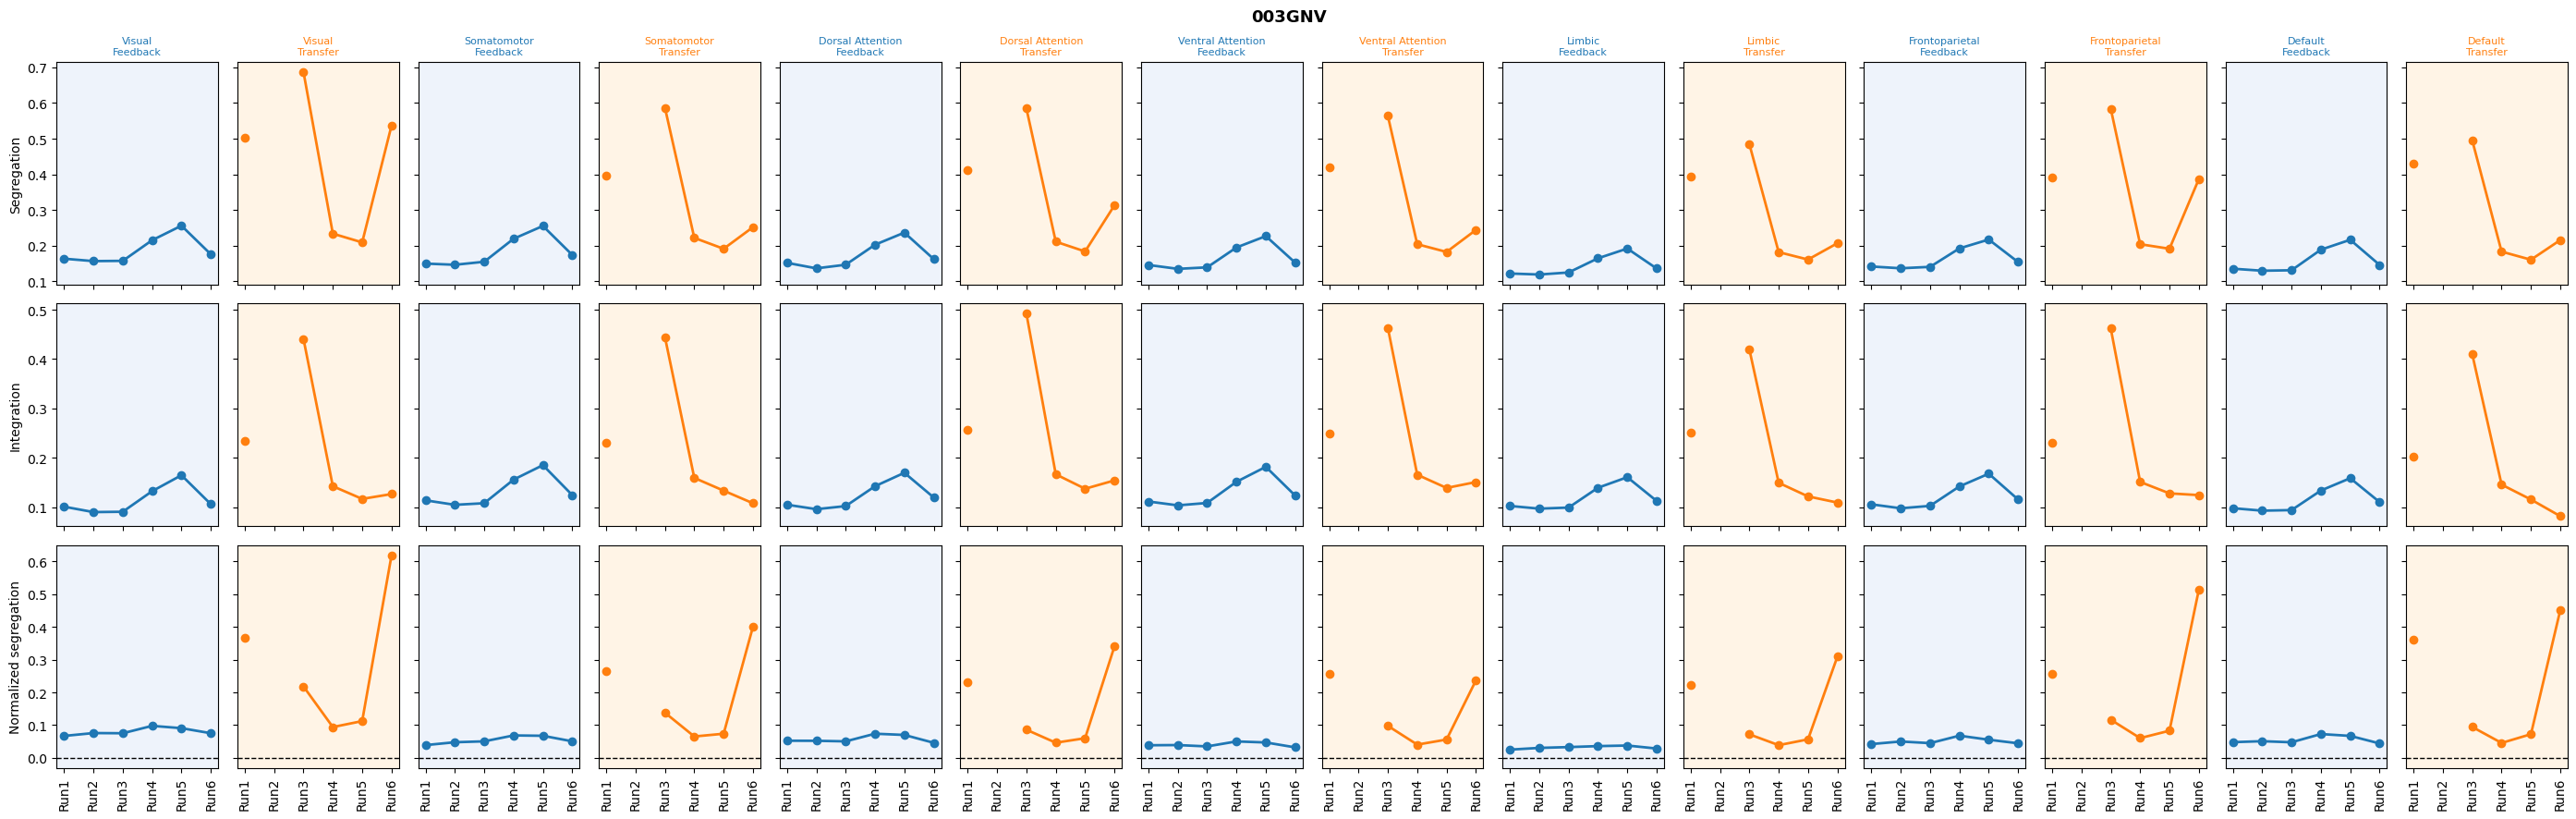

In [12]:
condition_colors = {
    "Feedback": "#1f77b4",   # blue
    "Transfer": "#ff7f0e",   # orange
    "Rest": "#2ca02c",       # green (optional, if you have Rest)
}

# If your runs are named Run1..Run6:
RUN_ORDER = ["Run1", "Run2", "Run3", "Run4", "Run5", "Run6"]

SUBJECT_ID = "003GNV"

METRICS = [
    ("segregation", "Segregation"),
    ("integration", "Integration"),
    ("normalized_segregation", "Normalized segregation"),
]


def plot_subject_per_network(all_data, subject_id, yeo_names,
                             condition_colors=condition_colors,
                             run_order=RUN_ORDER):
    from collections import defaultdict

    subj = all_data[subject_id]

    # accumulate per (run, condition)
    acc = defaultdict(lambda: {
        "segregation": [],
        "integration": [],
        "normalized_segregation": [],
    })

    for sess_id, sess_runs in subj["sessions"].items():
        for run_key, rd in sess_runs.items():
            key = (run_key, rd["condition"])
            acc[key]["segregation"].append(rd["segregation"])
            acc[key]["integration"].append(rd["integration"])
            acc[key]["normalized_segregation"].append(rd["normalized_segregation"])

    # compute mean and counts per metric
    averaged = {}
    counts = {}

    for (run_key, cond), mlists in acc.items():
        averaged[(run_key, cond)] = {}
        counts[(run_key, cond)] = {}
        for m, v in mlists.items():
            arr = np.vstack(v)  # shape: n_sessions × 7
            averaged[(run_key, cond)][m] = np.nanmean(arr, axis=0)
            counts[(run_key, cond)][m] = np.sum(~np.isnan(arr), axis=0)

    x = np.arange(len(run_order))

    fig, axes = plt.subplots(
        3, len(yeo_names) * 2,
        figsize=(4 * len(yeo_names), 9),
        sharey="row", sharex=True
    )
    fig.suptitle(subject_id, fontsize=13, fontweight="bold")

    for net_idx, net_name in enumerate(yeo_names):
        for cond_idx, cond in enumerate(["Feedback", "Transfer"]):
            col = net_idx * 2 + cond_idx
            color = condition_colors.get(cond, "black")

            for row_idx, (metric, title) in enumerate(METRICS):
                ax = axes[row_idx, col]

                y = np.full(len(run_order), np.nan)
                for (run_key, c), vals in averaged.items():
                    if c == cond and run_key in run_order:
                        idx = run_order.index(run_key)

                        mean_val = vals[metric][net_idx]
                        n_points = counts[(run_key, c)][metric][net_idx]

                        if n_points > 0:
                            # divide by sqrt(n_points)
                            y[idx] = mean_val / np.sqrt(n_points)
                        else:
                            y[idx] = np.nan

                ax.plot(x, y, color=color, linewidth=2, marker="o")
                ax.set_xticks(x)
                ax.set_xticklabels(run_order, rotation=90)

                if metric == "normalized_segregation":
                    ax.axhline(0, linestyle="--", linewidth=1, color="black")
                if col == 0:
                    ax.set_ylabel(title)

                if row_idx == 0:
                    ax.set_title(f"{net_name}\n{cond}", color=color, fontsize=8)

            # light background to visually group the pair
            for row_idx in range(3):
                axes[row_idx, col].set_facecolor(
                    "#eef3fb" if cond == "Feedback" else "#fff4e6"
                )

    plt.tight_layout()
    plt.show()


plot_subject_per_network(all_data, SUBJECT_ID, YEO_NAMES)


## Appendix — Data Structure Inspection

In [13]:
# Top level
print("Subjects:", list(all_data.keys()))
print()

# Drill into first subject
sid = list(all_data.keys())[0]
subj = all_data[sid]
print(f"Subject '{sid}' keys:", list(subj.keys()))
print(f"  yeo_labels shape: {subj['yeo_labels'].shape}")
print(f"  yeo_labels unique values: {np.unique(subj['yeo_labels'])}")
print()

# Sessions
print(f"  Sessions: {list(subj['sessions'].keys())}")
print()

# Drill into first session
sess_id = list(subj['sessions'].keys())[0]
sess = subj['sessions'][sess_id]
print(f"  Session '{sess_id}' runs: {list(sess.keys())}")
print()

# Drill into first run
run_id = list(sess.keys())[0]
run = sess[run_id]
print(f"  Run '{run_id}' keys: {list(run.keys())}")
for k, v in run.items():
    shape = getattr(v, 'shape', None)
    if shape:
        print(f"    {k}: {type(v).__name__}  shape={shape}  min={np.nanmin(v):.3f}  max={np.nanmax(v):.3f}")
    else:
        print(f"    {k}: {v}")


Subjects: ['003GNV', '004GNV', '005GNV', '008GNV', '012GNV', '013GNV', '016GNV', '020GNV', '021GNV', '023GNV', '025GNV', '026GNV', '034GNV', '037GNV', '041GNV', '043GNV', '048GNV', '049GNV', '054GNV', '056GNV']

Subject '003GNV' keys: ['sessions', 'yeo_labels']
  yeo_labels shape: (219,)
  yeo_labels unique values: [1 2 3 4 5 6 7 8 9]

  Sessions: ['V01', 'V02', 'V03', 'V04', 'V05', 'V06', 'V07', 'V08', 'V09', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15']

  Session 'V01' runs: ['Run1', 'Run2', 'Run3', 'Run4', 'Run5', 'Run6']

  Run 'Run1' keys: ['condition', 'FC', 'segregation', 'integration', 'normalized_segregation', 'pc_parcel', 'wmd_parcel', 'yeo_labels_cortical']
    condition: Feedback
    FC: ndarray  shape=(219, 219)  min=-0.245  max=1.000
    segregation: ndarray  shape=(7,)  min=0.534  max=0.689
    integration: ndarray  shape=(7,)  min=0.473  max=0.548
    normalized_segregation: ndarray  shape=(7,)  min=0.030  max=0.186
    pc_parcel: ndarray  shape=(200,)  min=0.791  max=0.84